<a href="https://colab.research.google.com/github/danielmogo25/Proyecto-UNAL-ChatMP3/blob/main/Chat_mp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importamos las librerias que vamos a usar
import requests
import sqlite3


In [ ]:

#Creacion base de datos
conn = sqlite3.connect('base_datos_chat_mp3.sqlite')
cur=conn.cursor()
cur.executescript('''
DROP TABLE IF EXISTS Track;
DROP TABLE IF EXISTS Artista;
DROP TABLE IF EXISTS Genero;
DROP TABLE IF EXISTS Album;

CREATE TABLE Track(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
titulo TEXT UNIQUE,
artista_id,
album_id INTEGER,
duracion INTEGER,
fecha INTEGER,
preview INTEGER
);
CREATE TABLE Artista(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
);
CREATE TABLE Album(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
);
CREATE TABLE Genero(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
)
''')
conn.commit()


In [18]:
def descargar_imagen(url,nombre_archivo):
  """
    Descarga un archivo binario desde una URL y lo guarda en disco.

    Args:
        url (str): URL del archivo a descargar.
        nombre_archivo (str): nombre con el que se guardará localmente.

    Returns:
        bool: True si la descarga fue exitosa, False si falló.
    """
  try:
      respuesta = requests.get(url, stream=True, timeout=10)
      respuesta.raise_for_status()

      with open(nombre_archivo, "wb") as archivo:
          for bloque in respuesta.iter_content(chunk_size=8192):
              archivo.write(bloque)

      print(f" Archivo guardado como '{nombre_archivo}'")
      return True

  except requests.exceptions.Timeout:
      print(" La descarga tardó demasiado y se canceló.")
  except requests.exceptions.RequestException as error:
      print(f" No se pudo descargar el archivo: {error}")

  return False

ESTADO RESPUESTA None

DATOS JSON [{'wrapperType': 'track', 'kind': 'song', 'artistId': 368183298, 'collectionId': 1440871877, 'trackId': 1440871897, 'artistName': 'Kendrick Lamar', 'collectionName': 'To Pimp a Butterfly', 'trackName': 'Mortal Man', 'collectionCensoredName': 'To Pimp a Butterfly', 'trackCensoredName': 'Mortal Man', 'artistViewUrl': 'https://music.apple.com/us/artist/kendrick-lamar/368183298?uo=4', 'collectionViewUrl': 'https://music.apple.com/us/album/mortal-man/1440871877?i=1440871897&uo=4', 'trackViewUrl': 'https://music.apple.com/us/album/mortal-man/1440871877?i=1440871897&uo=4', 'previewUrl': 'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview115/v4/a1/7f/3f/a17f3fee-08bd-814f-6cdb-76c2998143a3/mzaf_5177548524236383047.plus.aac.p.m4a', 'artworkUrl30': 'https://is1-ssl.mzstatic.com/image/thumb/Music112/v4/b5/a6/91/b5a69171-5232-3d5b-9c15-8963802f83dd/15UMGIM15814.rgb.jpg/30x30bb.jpg', 'artworkUrl60': 'https://is1-ssl.mzstatic.com/image/thumb/Music112/v4/b

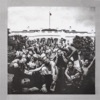

In [27]:
def buscador_por_termino(termino,limite):
    #url API Searh endpoint
    url="https://itunes.apple.com/search"
    #Parametros necesarios (term=your+search+query(termino),media:"music",entity:"song",limit:"limite"
    params = {
        "term": termino,
        "media": "music",
        "entity": "song",
        "limit": limite
    }
    respuesta_1= requests.get(url,params=params,timeout=10)
    #En esta libreria se tiene que poner asi params para adjuntar nuestro diccionario a la url
    print("ESTADO RESPUESTA",respuesta_1.raise_for_status())# ver si esta bien
    resultados=respuesta_1.json()["results"]#JSON de la lista con los datos
    print("="*50)
    print("\nDATOS JSON",resultados)
    for dato in resultados:
        print("\n")
        print("/"*50)
        titulo=dato.get('trackName')
        album=dato.get("collectionName")
        artista=dato.get('artistName')
        preview=dato.get('previewUrl')
        fecha=int(dato.get('releaseDate')[:4])
        genero= dato.get('primaryGenreName')
        #---------------CALCULO DURACION-----------------
        milisegundos= dato.get('trackTimeMillis')
        minutos = milisegundos// 60000 #De milisegundos a minutos
        segundos = (milisegundos % 60000) // 1000
        duracion =f"{minutos}:{segundos:02d}"#formato estandar de segundos
        #---------------DESCARGAR E IMPRIMIR IMAGEN-----------------
        imagen_url=dato.get('artworkUrl100')
        nombre_limpio = "".join(c for c in titulo if c.isalnum() or c in (" ", "_", "-")).rstrip()#como los nombres de las canciones pueden tener caracteres especiales estos se eliminan para no dañar el codigo
        archivo_local=f"{nombre_limpio}.jpg"
        descargar_imagen(imagen_url,archivo_local)
        print("="*50)
        print(f"TITULO:{titulo}\nALBUM:{album}\nARTISTA:{artista}\nGENERO:{genero}\nDURACION:{duracion}\nPREVIEW LINK:{preview}\nAÑO SALIDA:{fecha}")
        #Mostrar imagen
        from IPython.display import Image, display
        display(Image(archivo_local))

    #url API lookup endpoint para sacar la meta data
    url_search_point="https://itunes.apple.com/lookup"
    #
buscador_por_termino("mortal man",1)

In [ ]:
#url API Searh endpoint
url="https://itunes.apple.com/search"
#Parametros necesarios (term=your+search+query )
#url API lookup endpoint para sacar la meta data
url_search_point="https://itunes.apple.com/lookup"
#
for dato in resultados:
    titulo=dato.get()

NameError: name 'resultados' is not defined